In [1]:
%cd ..

/Users/v1adych/inno/big-data/ass1


In [2]:
import polars as pl

bench_path = "report/benchmark_results.tsv"
df = pl.read_csv(bench_path, separator="\t")

# basic cleanup
df = df.with_columns(
    pl.col("database").str.to_lowercase(),
    pl.col("query").str.to_uppercase(),
)

stats = (
    df.group_by(["database", "query"])
    .agg(
        pl.len().alias("n"),
        pl.col("execution_time_s").mean().alias("mean_s"),
        pl.col("execution_time_s").std(ddof=1).alias("std_s"),
        pl.col("execution_time_s").min().alias("min_s"),
        pl.col("execution_time_s").max().alias("max_s"),
    )
    .sort(["database", "query"])
)

stats

database,query,n,mean_s,std_s,min_s,max_s
str,str,u32,f64,f64,f64,f64
"""citus""","""Q1""",3,31.294771,2.565012,29.546443,34.239394
"""citus""","""Q2""",3,46.46657,4.380112,41.491729,49.743671
"""citus""","""Q3""",3,57.012501,2.335323,54.469825,59.061549
"""citus""","""Q4""",3,0.299663,0.009562,0.289233,0.308014
"""mongo""","""Q1""",3,266.851377,11.004281,254.386098,275.218684
…,…,…,…,…,…,…
"""postgres""","""Q4""",3,0.099332,0.002993,0.096549,0.102499
"""scylla""","""Q1""",3,0.003924,0.000879,0.00326,0.00492
"""scylla""","""Q2""",3,2.392484,0.152612,2.223974,2.521391


In [7]:
# Fill these from your setup notes (same values you used in ingestion_table.md)
resource_info = pl.DataFrame(
    [
        {"database": "postgres", "Database Setup": "A single server", "CPU cores allocated": 8, "Main Memory usage": "7.654GiB"},
        {"database": "citus", "Database Setup": "A cluster of 3 nodes", "CPU cores allocated": 8, "Main Memory usage": "7.654GiB"},
        {"database": "scylla", "Database Setup": "A cluster of 3 nodes", "CPU cores allocated": 6, "Main Memory usage": "6GiB"},
        {"database": "mongo", "Database Setup": "A replica set of 3 nodes", "CPU cores allocated": 8, "Main Memory usage": "7.654GiB"},
    ]
)

print(resource_info.to_pandas().to_markdown(index=False))

| database   | Database Setup           |   CPU cores allocated | Main Memory usage   |
|:-----------|:-------------------------|----------------------:|:--------------------|
| postgres   | A single server          |                     8 | 7.654GiB            |
| citus      | A cluster of 3 nodes     |                     8 | 7.654GiB            |
| scylla     | A cluster of 3 nodes     |                     6 | 6GiB                |
| mongo      | A replica set of 3 nodes |                     8 | 7.654GiB            |


In [8]:

mean_wide = stats.select(["database", "query", "mean_s"]).pivot(on="query", index="database", values="mean_s").sort("database")

summary = mean_wide.join(resource_info, on="database", how="left").select(
    pl.col("database").alias("Database"),
    pl.col("Q1"),
    pl.col("Q2"),
    pl.col("Q3"),
    pl.col("Q4"),
    pl.col("Database Setup"),
    pl.col("CPU cores allocated"),
    pl.col("Main Memory usage"),
)

# pretty formatting for display/export
summary_fmt = summary.with_columns(pl.col("Q1", "Q2", "Q3", "Q4").map_elements(lambda x: f"{x:.3f}s", return_dtype=pl.Utf8))

summary_fmt

Database,Q1,Q2,Q3,Q4,Database Setup,CPU cores allocated,Main Memory usage
str,str,str,str,str,str,i64,str
"""citus""","""31.295s""","""46.467s""","""57.013s""","""0.300s""","""A cluster of 3 nodes""",8,"""7.654GiB"""
"""mongo""","""266.851s""","""0.205s""","""121.051s""","""1.085s""","""A replica set of 3 nodes""",8,"""7.654GiB"""
"""postgres""","""4.436s""","""5.417s""","""62.556s""","""0.099s""","""A single server""",8,"""7.654GiB"""
"""scylla""","""0.004s""","""2.392s""","""0.002s""","""0.054s""","""A cluster of 3 nodes""",6,"""6GiB"""


In [9]:
print(summary_fmt.to_pandas().to_markdown(index=False))

| Database   | Q1       | Q2      | Q3       | Q4     | Database Setup           |   CPU cores allocated | Main Memory usage   |
|:-----------|:---------|:--------|:---------|:-------|:-------------------------|----------------------:|:--------------------|
| citus      | 31.295s  | 46.467s | 57.013s  | 0.300s | A cluster of 3 nodes     |                     8 | 7.654GiB            |
| mongo      | 266.851s | 0.205s  | 121.051s | 1.085s | A replica set of 3 nodes |                     8 | 7.654GiB            |
| postgres   | 4.436s   | 5.417s  | 62.556s  | 0.099s | A single server          |                     8 | 7.654GiB            |
| scylla     | 0.004s   | 2.392s  | 0.002s   | 0.054s | A cluster of 3 nodes     |                     6 | 6GiB                |


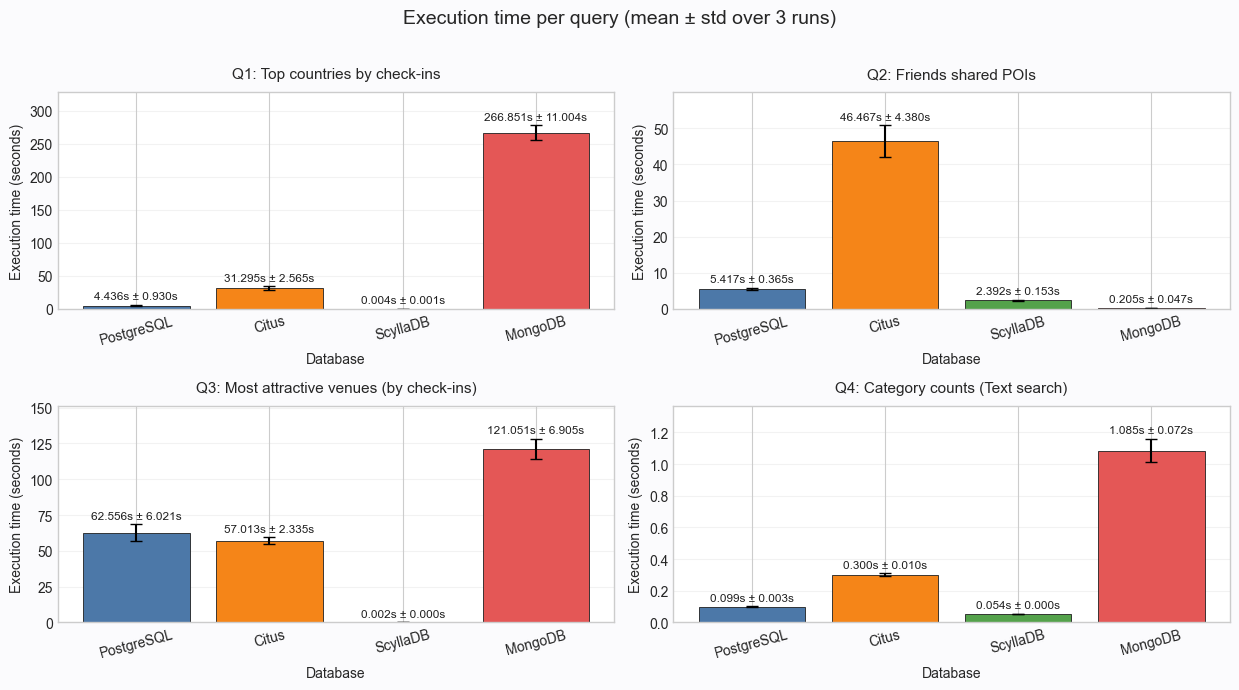

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

order_db = ["postgres", "citus", "scylla", "mongo"]
order_q = ["Q1", "Q2", "Q3", "Q4"]
query_titles = {
    "Q1": "Q1: Top countries by check-ins",
    "Q2": "Q2: Friends shared POIs",
    "Q3": "Q3: Most attractive venues (by check-ins)",
    "Q4": "Q4: Category counts (Text search)",
}
pretty_db = {"postgres": "PostgreSQL", "citus": "Citus", "scylla": "ScyllaDB", "mongo": "MongoDB"}

colors = {
    "postgres": "#4C78A8",
    "citus": "#F58518",
    "scylla": "#54A24B",
    "mongo": "#E45756",
}

plot_df = stats.filter(pl.col("database").is_in(order_db) & pl.col("query").is_in(order_q))
means = {(r["database"], r["query"]): float(r["mean_s"]) for r in plot_df.select(["database", "query", "mean_s"]).to_dicts()}
stds = {(r["database"], r["query"]): float(r["std_s"]) for r in plot_df.select(["database", "query", "std_s"]).to_dicts()}

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7), sharey=False)
fig.patch.set_facecolor("#fbfbfd")
axes = axes.ravel()

for ax, q in zip(axes, order_q):
    db_labels = [pretty_db[d] for d in order_db]
    y = np.array([means[(db, q)] for db in order_db], dtype=float)
    e = np.array([stds[(db, q)] for db in order_db], dtype=float)

    bars = ax.bar(
        db_labels,
        y,
        yerr=e,
        capsize=4,
        color=[colors[d] for d in order_db],
        edgecolor="#1f1f1f",
        linewidth=0.6,
    )

    ax.set_title(query_titles.get(q, q), fontsize=11, pad=10)
    ax.set_ylabel("Execution time (seconds)")
    ax.set_xlabel("Database")
    ax.tick_params(axis="x", rotation=15)

    ymax = float(np.max(y + e)) if len(y) else 1.0
    ax.set_ylim(0, ymax * 1.18 + 1e-9)

    y_offset = ymax * 0.02
    for rect, mean_s, std_s in zip(bars, y, e):
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height() + std_s + y_offset,
            f"{mean_s:.3f}s ± {std_s:.3f}s",
            ha="center",
            va="bottom",
            fontsize=8.5,
            color="#1f1f1f",
        )

    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_facecolor("#ffffff")

fig.suptitle("Execution time per query (mean ± std over 3 runs)", fontsize=14, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.965])
fig.savefig("report/assets/benchmark_per_query_grid.png", dpi=220, bbox_inches="tight")
plt.show()